# SOMD 2026 — Corpus Statistics
Computes all statistics needed for the system description paper.

## 0. Imports & Setup

In [1]:
import json
import re
from collections import defaultdict, Counter
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

try:
    from rapidfuzz import fuzz
    HAS_RAPIDFUZZ = True
except ImportError:
    HAS_RAPIDFUZZ = False
    print("rapidfuzz not found. Install with: pip install rapidfuzz")
    print("Lexical similarity stats will be skipped.")

sns.set_theme(style='whitegrid', palette='muted')
print('Ready.')

Ready.


## 1. Load Data

In [2]:
# ── Paths — adjust as needed ──────────────────────────────────────────────────
TRAIN_DATA_PATH   = '../data/SOMD 2026/subtask 2/train_data.jsonl'
TRAIN_LABELS_PATH = '../data/SOMD 2026/subtask 2/train_labels.json'

# ── Load mentions ─────────────────────────────────────────────────────────────
mentions = []
with open(TRAIN_DATA_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            mentions.append(json.loads(line))

# ── Load labels (list of clusters, each cluster = list of mention_ids) ────────
with open(TRAIN_LABELS_PATH) as f:
    clusters = json.load(f)

# ── Index mentions by id ──────────────────────────────────────────────────────
mention_by_id = {m['mention_id']: m for m in mentions}

print(f'Loaded {len(mentions):,} mentions')
print(f'Loaded {len(clusters):,} coreference clusters')
print(f'\nExample mention:')
print(json.dumps(mentions[0], indent=2))
print(f'\nExample cluster (first 5 ids): {clusters[0][:5]}')

Loaded 2,860 mentions
Loaded 699 coreference clusters

Example mention:
{
  "mention": "NQuery Advisor",
  "mention_id": "1efe624d70",
  "start": 0,
  "end": 14,
  "type": "Application_Usage",
  "docid": "3ca094cf",
  "relations": [
    {
      "mention": "3 . 0",
      "mention_id": "PMC6343886/sentence88/T4",
      "start": 36,
      "end": 41,
      "type": "Version"
    }
  ],
  "sentence": "NQuery Advisor by StatsSols version 3 . 0 was used to calculate sample size ."
}

Example cluster (first 5 ids): ['1efe624d70']


## 2. Build Cluster Objects
Each cluster is a list of full mention dicts.

In [3]:
# Resolve mention_ids to full mention dicts
# Skip ids not found in mention_by_id (edge case safety)
cluster_mentions = [
    [mention_by_id[mid] for mid in cluster if mid in mention_by_id]
    for cluster in clusters
]

# Filter out empty clusters
cluster_mentions = [c for c in cluster_mentions if len(c) > 0]

print(f'Resolved clusters : {len(cluster_mentions):,}')
print(f'Cluster sizes     : min={min(len(c) for c in cluster_mentions)}, '
      f'max={max(len(c) for c in cluster_mentions)}, '
      f'mean={np.mean([len(c) for c in cluster_mentions]):.2f}')

Resolved clusters : 699
Cluster sizes     : min=1, max=366, mean=4.09


## 3. Helper Functions

In [4]:
def mention_category(s):
    s = s.strip()
    if re.search(r'(https?://|www\.)', s, re.IGNORECASE):
        return 'URL'
    if re.search(r'(v\.?\s*\d|\d+\.\d+|R\d{4})', s, re.IGNORECASE):
        return 'Version-qualified'
    if re.match(r'^[A-Z][A-Z0-9\-]{1,7}$', s):
        return 'Abbreviation'
    return 'Full name'


def surface_variation(cluster):
    """Number of unique lowercased surface forms in a cluster."""
    return len(set(m['mention'].strip().lower() for m in cluster))


def doc_count(cluster):
    """Number of distinct documents a cluster spans."""
    return len(set(m['docid'] for m in cluster))


def mean_pairwise_fuzzy(cluster):
    """Mean pairwise token-sort-ratio within a cluster."""
    if not HAS_RAPIDFUZZ or len(cluster) < 2:
        return None
    strings = [m['mention'].strip() for m in cluster]
    scores = [fuzz.token_sort_ratio(a, b) / 100.0
              for a, b in combinations(strings, 2)]
    return np.mean(scores)

print('Helpers defined.')

Helpers defined.


## 4. Basic Corpus Statistics

In [5]:
n_mentions      = len(mentions)
n_clusters      = len(cluster_mentions)
unique_surfaces = set(m['mention'].strip().lower() for m in mentions)
unique_docs     = set(m['docid'] for m in mentions)
unique_sents    = set((m['docid'], m['sentence']) for m in mentions)

print('── Basic Corpus Statistics ──')
print(f'  Documents (unique)       : {len(unique_docs):,}')
print(f'  Sentences (unique)       : {len(unique_sents):,}')
print(f'  Mention instances        : {n_mentions:,}   (tokens)')
print(f'  Unique surface forms     : {len(unique_surfaces):,}   (types)')
print(f'  Type / Token ratio       : {len(unique_surfaces)/n_mentions:.3f}')
print(f'  Coreference clusters     : {n_clusters:,}')

── Basic Corpus Statistics ──
  Documents (unique)       : 967
  Sentences (unique)       : 2,140
  Mention instances        : 2,860   (tokens)
  Unique surface forms     : 791   (types)
  Type / Token ratio       : 0.277
  Coreference clusters     : 699


## 5. Coreference Chain Statistics

── Coreference Chain Statistics ──
  Avg chain length         : 4.09
  Median chain length      : 1.0
  Max chain length         : 366
  Singletons (len=1)       : 367  (52.5%)
  Pairs (len=2)            : 123  (17.6%)
  Chains len >= 3          : 209  (29.9%)


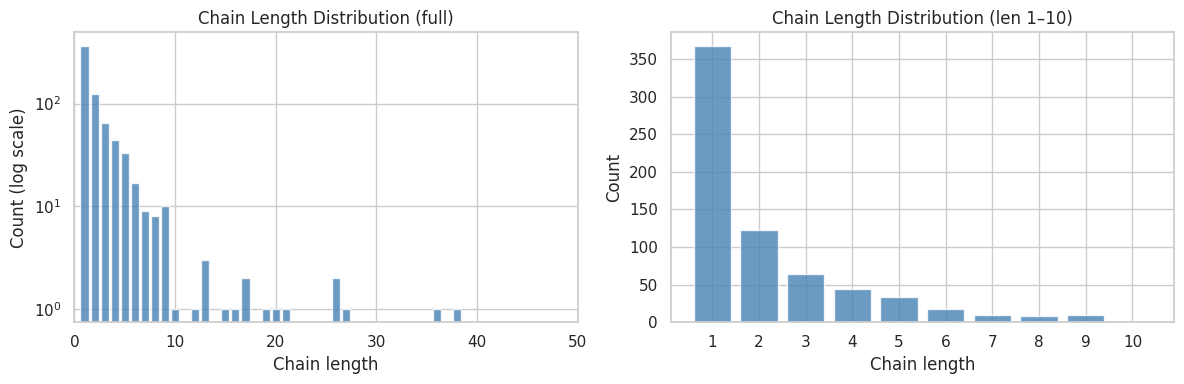

Saved: chain_length_dist.pdf


In [6]:
chain_lengths  = [len(c) for c in cluster_mentions]
singletons     = sum(1 for l in chain_lengths if l == 1)
pairs          = sum(1 for l in chain_lengths if l == 2)
chains_3plus   = sum(1 for l in chain_lengths if l >= 3)

print('── Coreference Chain Statistics ──')
print(f'  Avg chain length         : {np.mean(chain_lengths):.2f}')
print(f'  Median chain length      : {np.median(chain_lengths):.1f}')
print(f'  Max chain length         : {max(chain_lengths)}')
print(f'  Singletons (len=1)       : {singletons:,}  ({100*singletons/n_clusters:.1f}%)')
print(f'  Pairs (len=2)            : {pairs:,}  ({100*pairs/n_clusters:.1f}%)')
print(f'  Chains len >= 3          : {chains_3plus:,}  ({100*chains_3plus/n_clusters:.1f}%)')

# ── Plot chain length distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution (log scale)
length_counts = Counter(chain_lengths)
axes[0].bar(length_counts.keys(), length_counts.values(), color='steelblue', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_xlabel('Chain length')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Chain Length Distribution (full)')
axes[0].set_xlim(0, min(max(chain_lengths)+1, 50))

# Zoomed: length 1-10
short = {k: v for k, v in length_counts.items() if k <= 10}
axes[1].bar(short.keys(), short.values(), color='steelblue', alpha=0.8)
axes[1].set_xlabel('Chain length')
axes[1].set_ylabel('Count')
axes[1].set_title('Chain Length Distribution (len 1–10)')
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig('chain_length_dist.pdf', bbox_inches='tight')
plt.show()
print('Saved: chain_length_dist.pdf')

## 6. Mention-Level Statistics

── Mention-Level Statistics ──
  Avg span length (chars)      : 7.64
  Median span length (chars)   : 6.0
  Max span length (chars)      : 71
  Avg mentions per document    : 2.96
  Max mentions in a document   : 40

  Surface form categories:
    Full name             : 1,947  (68.1%)
    Abbreviation          :   913  (31.9%)

  Mention type distribution:
    Application_Usage                            : 1,715  (60.0%)
    ProgrammingEnvironment_Usage                 :   292  (10.2%)
    Application_Mention                          :   189  (6.6%)
    PlugIn_Usage                                 :   185  (6.5%)
    Application_Creation                         :   169  (5.9%)
    OperatingSystem_Usage                        :   118  (4.1%)
    Application_Deposition                       :    69  (2.4%)
    ProgrammingEnvironment_Mention               :    35  (1.2%)
    PlugIn_Creation                              :    26  (0.9%)
    OperatingSystem_Mention                      :   

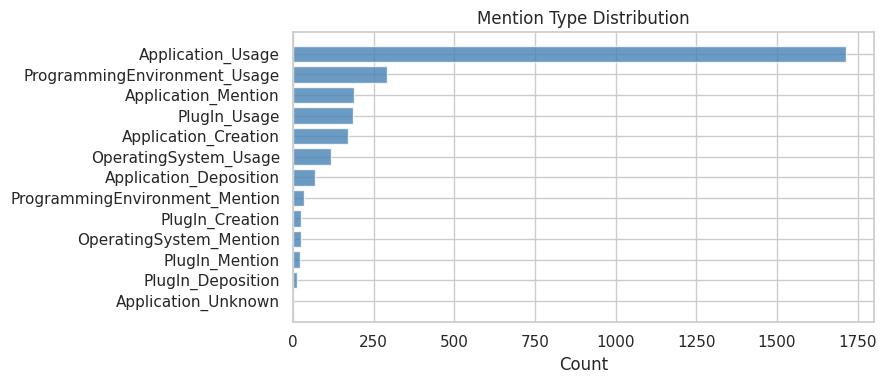

Saved: mention_types.pdf


In [7]:
span_lengths = [m['end'] - m['start'] for m in mentions]
doc_mention_counts = Counter(m['docid'] for m in mentions)
categories = Counter(mention_category(m['mention']) for m in mentions)
type_dist  = Counter(m.get('type', 'unknown') for m in mentions)

print('── Mention-Level Statistics ──')
print(f'  Avg span length (chars)      : {np.mean(span_lengths):.2f}')
print(f'  Median span length (chars)   : {np.median(span_lengths):.1f}')
print(f'  Max span length (chars)      : {max(span_lengths)}')
print(f'  Avg mentions per document    : {np.mean(list(doc_mention_counts.values())):.2f}')
print(f'  Max mentions in a document   : {max(doc_mention_counts.values())}')

print(f'\n  Surface form categories:')
for cat, count in categories.most_common():
    print(f'    {cat:22s}: {count:5,}  ({100*count/n_mentions:.1f}%)')

print(f'\n  Mention type distribution:')
for t, count in type_dist.most_common():
    print(f'    {t:45s}: {count:5,}  ({100*count/n_mentions:.1f}%)')

# ── Plot mention type distribution ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
types, counts = zip(*type_dist.most_common())
ax.barh(types, counts, color='steelblue', alpha=0.8)
ax.set_xlabel('Count')
ax.set_title('Mention Type Distribution')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('mention_types.pdf', bbox_inches='tight')
plt.show()
print('Saved: mention_types.pdf')

## 7. Cross-Document Statistics

── Cross-Document Statistics ──
  Cross-document clusters       : 146  (20.9%)
  Within-document clusters      : 553  (79.1%)
  Avg documents per cluster     : 2.87
  Max documents per cluster     : 320
  Avg unique surface forms/cluster : 1.13
  Clusters with surface variation  : 64  (9.2%)


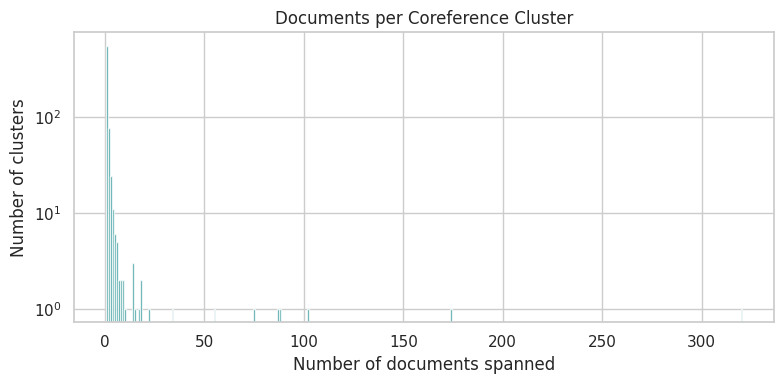

Saved: docs_per_cluster.pdf


In [8]:
docs_per_cluster    = [doc_count(c) for c in cluster_mentions]
cross_doc_clusters  = sum(1 for d in docs_per_cluster if d > 1)
within_doc_clusters = n_clusters - cross_doc_clusters
surface_vars        = [surface_variation(c) for c in cluster_mentions]
clusters_with_var   = sum(1 for v in surface_vars if v > 1)

print('── Cross-Document Statistics ──')
print(f'  Cross-document clusters       : {cross_doc_clusters:,}  ({100*cross_doc_clusters/n_clusters:.1f}%)')
print(f'  Within-document clusters      : {within_doc_clusters:,}  ({100*within_doc_clusters/n_clusters:.1f}%)')
print(f'  Avg documents per cluster     : {np.mean(docs_per_cluster):.2f}')
print(f'  Max documents per cluster     : {max(docs_per_cluster)}')
print(f'  Avg unique surface forms/cluster : {np.mean(surface_vars):.2f}')
print(f'  Clusters with surface variation  : {clusters_with_var:,}  ({100*clusters_with_var/n_clusters:.1f}%)')

# ── Plot docs per cluster distribution ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
doc_dist = Counter(docs_per_cluster)
ax.bar(doc_dist.keys(), doc_dist.values(), color='teal', alpha=0.8)
ax.set_xlabel('Number of documents spanned')
ax.set_ylabel('Number of clusters')
ax.set_title('Documents per Coreference Cluster')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('docs_per_cluster.pdf', bbox_inches='tight')
plt.show()
print('Saved: docs_per_cluster.pdf')

In [9]:
# ── Cross-document rate excluding singletons ──────────────────────────────────
non_singleton_clusters = [c for c in cluster_mentions if len(c) > 1]
n_non_singleton = len(non_singleton_clusters)

docs_per_non_singleton = [doc_count(c) for c in non_singleton_clusters]
cross_doc_non_singleton = sum(1 for d in docs_per_non_singleton if d > 1)
within_doc_non_singleton = n_non_singleton - cross_doc_non_singleton

print('── Cross-Document Statistics (singletons excluded) ──')
print(f'  Non-singleton clusters        : {n_non_singleton:,}')
print(f'  Cross-document clusters       : {cross_doc_non_singleton:,}  ({100*cross_doc_non_singleton/n_non_singleton:.1f}%)')
print(f'  Within-document clusters      : {within_doc_non_singleton:,}  ({100*within_doc_non_singleton/n_non_singleton:.1f}%)')
print(f'  Avg documents per cluster     : {np.mean(docs_per_non_singleton):.2f}')

── Cross-Document Statistics (singletons excluded) ──
  Non-singleton clusters        : 332
  Cross-document clusters       : 146  (44.0%)
  Within-document clusters      : 186  (56.0%)
  Avg documents per cluster     : 4.94


## 8. Lexical Similarity Within Clusters

── Lexical Similarity Within Clusters (rapidfuzz token-sort-ratio) ──
  Clusters with >= 2 mentions  : 332
  Avg pairwise similarity      : 0.887
  Median pairwise similarity   : 1.000
  Clusters sim >= 0.80         : 268  (80.7%)
  Clusters sim >= 0.50         : 308  (92.8%)
  Clusters sim < 0.50          : 24  (7.2%)


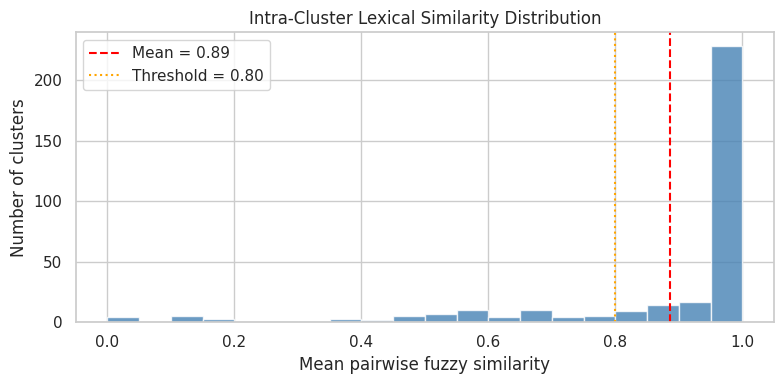

Saved: lexical_similarity.pdf


In [10]:
if HAS_RAPIDFUZZ:
    sim_scores = []
    for c in cluster_mentions:
        if len(c) >= 2:
            s = mean_pairwise_fuzzy(c)
            if s is not None:
                sim_scores.append(s)

    print('── Lexical Similarity Within Clusters (rapidfuzz token-sort-ratio) ──')
    print(f'  Clusters with >= 2 mentions  : {len(sim_scores):,}')
    print(f'  Avg pairwise similarity      : {np.mean(sim_scores):.3f}')
    print(f'  Median pairwise similarity   : {np.median(sim_scores):.3f}')
    print(f'  Clusters sim >= 0.80         : {sum(1 for s in sim_scores if s >= 0.8):,}  ({100*sum(1 for s in sim_scores if s >= 0.8)/len(sim_scores):.1f}%)')
    print(f'  Clusters sim >= 0.50         : {sum(1 for s in sim_scores if s >= 0.5):,}  ({100*sum(1 for s in sim_scores if s >= 0.5)/len(sim_scores):.1f}%)')
    print(f'  Clusters sim < 0.50          : {sum(1 for s in sim_scores if s < 0.5):,}  ({100*sum(1 for s in sim_scores if s < 0.5)/len(sim_scores):.1f}%)')

    # ── Plot similarity distribution ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(sim_scores, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(sim_scores), color='red', linestyle='--', label=f'Mean = {np.mean(sim_scores):.2f}')
    ax.axvline(0.8, color='orange', linestyle=':', label='Threshold = 0.80')
    ax.set_xlabel('Mean pairwise fuzzy similarity')
    ax.set_ylabel('Number of clusters')
    ax.set_title('Intra-Cluster Lexical Similarity Distribution')
    ax.legend()
    plt.tight_layout()
    plt.savefig('lexical_similarity.pdf', bbox_inches='tight')
    plt.show()
    print('Saved: lexical_similarity.pdf')
else:
    print('Skipped — install rapidfuzz to compute lexical similarity.')

## 9. Class Imbalance

In [11]:
n_total_pairs = n_mentions * (n_mentions - 1) // 2
n_coref_pairs = sum(len(c) * (len(c) - 1) // 2 for c in cluster_mentions)
n_non_coref   = n_total_pairs - n_coref_pairs
ratio         = n_non_coref / n_coref_pairs if n_coref_pairs > 0 else float('inf')

print('── Class Imbalance ──')
print(f'  Total mention pairs          : {n_total_pairs:,}')
print(f'  Coreferring pairs            : {n_coref_pairs:,}  ({100*n_coref_pairs/n_total_pairs:.4f}%)')
print(f'  Non-coreferring pairs        : {n_non_coref:,}')
print(f'  Imbalance ratio (neg/pos)    : {ratio:,.1f} : 1')

── Class Imbalance ──
  Total mention pairs          : 4,088,370
  Coreferring pairs            : 116,283  (2.8442%)
  Non-coreferring pairs        : 3,972,087
  Imbalance ratio (neg/pos)    : 34.2 : 1


## 10. LaTeX Table

In [12]:
stats = {
    'Documents':                        len(unique_docs),
    'Sentences with mentions':          len(unique_sents),
    'Mention instances':                n_mentions,
    'Unique surface forms':             len(unique_surfaces),
    'Coreference clusters':             n_clusters,
    'Avg chain length':                 f'{np.mean(chain_lengths):.2f}',
    'Max chain length':                 max(chain_lengths),
    'Singleton rate (\\%)':             f'{100*singletons/n_clusters:.1f}',
    'Cross-doc rate, all (\\%)':        f'{100*cross_doc_clusters/n_clusters:.1f}',
    'Cross-doc rate, non-singletons (\\%)': f'{100*cross_doc_non_singleton/n_non_singleton:.1f}',  # <- new
    'Avg surface forms / cluster':      f'{np.mean(surface_vars):.2f}',
    'Avg intra-cluster lexical sim.':   f'{np.mean(sim_scores):.3f}' if HAS_RAPIDFUZZ and sim_scores else '--',
}

if HAS_RAPIDFUZZ and sim_scores:
    stats['Avg intra-cluster lexical sim.'] = f'{np.mean(sim_scores):.3f}'

print('\\begin{table}[t]')
print('\\centering')
print('\\small')
print('\\caption{Corpus statistics for the SOMD 2026 training set.}')
print('\\label{tab:corpus_stats}')
print('\\renewcommand{\\arraystretch}{1.15}')
print('\\begin{tabular}{lc}')
print('\\toprule')
print('\\textbf{Statistic} & \\textbf{Value} \\\\')
print('\\midrule')
for label, val in stats.items():
    print(f'{label} & {val} \\\\')
print('\\bottomrule')
print('\\end{tabular}')
print('\\end{table}')

\begin{table}[t]
\centering
\small
\caption{Corpus statistics for the SOMD 2026 training set.}
\label{tab:corpus_stats}
\renewcommand{\arraystretch}{1.15}
\begin{tabular}{lc}
\toprule
\textbf{Statistic} & \textbf{Value} \\
\midrule
Documents & 967 \\
Sentences with mentions & 2140 \\
Mention instances & 2860 \\
Unique surface forms & 791 \\
Coreference clusters & 699 \\
Avg chain length & 4.09 \\
Max chain length & 366 \\
Singleton rate (\%) & 52.5 \\
Cross-doc rate, all (\%) & 20.9 \\
Cross-doc rate, non-singletons (\%) & 44.0 \\
Avg surface forms / cluster & 1.13 \\
Avg intra-cluster lexical sim. & 0.887 \\
\bottomrule
\end{tabular}
\end{table}


In [13]:
lengths = []
for e in clusters:
    lengths.append(len(e))


In [14]:
np.mean(lengths)

np.float64(4.091559370529327)

In [15]:
len(clusters)

699